# Cvičení: Obecné regresní modely (Lineární, polynomiální a nelineární regrese)
**Autor:** matěj Bureš
  
**Cíl:** Porovnání modelů na syntetických a reálných datech.

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from scipy.optimize import curve_fit
import warnings
warnings.filterwarnings('ignore') # Pro čistší výstup

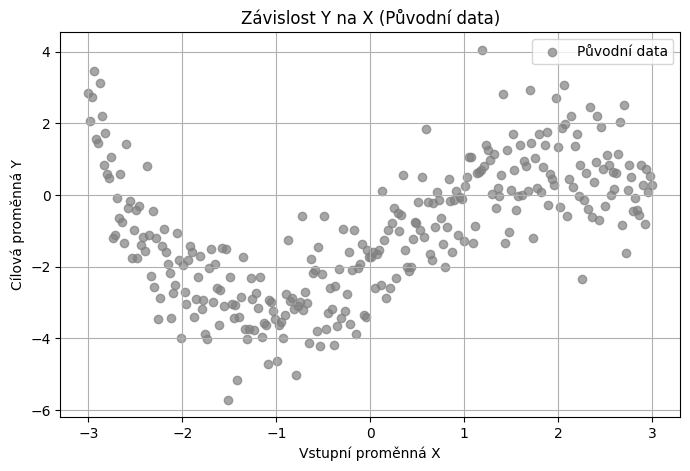

In [11]:
# 1. Načtení datasetu
df = pd.read_csv('Synthetic_dataset_1.csv')

# Úprava na správný tvar pro Scikit-Learn (X musí být 2D pole)
X = df[['X']].values
y = df['Y'].values

# 2. Vytvoření bodového grafu
plt.figure(figsize=(8, 5))
plt.scatter(X, y, color='gray', label='Původní data', alpha=0.7)
plt.title('Závislost Y na X (Původní data)')
plt.xlabel('Vstupní proměnná X')
plt.ylabel('Cílová proměnná Y')
plt.legend()
plt.grid(True)

# Uložení grafu do png
plt.savefig('scatterplot_data.png', dpi=300)
plt.show()

In [12]:
# 3. a 4. Trénování modelů a výpočet metrik
degrees = [1, 2, 3, 4, 5, 6, 7] # 1 je lineární regrese, zbytek jsou polynomy
results = []
models = {} # Uložíme si modely pro pozdější vykreslení

for d in degrees:
    if d == 1:
        # Lineární regrese
        model = LinearRegression()
        X_poly = X
    else:
        # Polynomiální regrese
        poly_features = PolynomialFeatures(degree=d)
        X_poly = poly_features.fit_transform(X)
        model = LinearRegression()

    model.fit(X_poly, y)
    y_pred = model.predict(X_poly)
    models[d] = model # uložení modelu

    # Výpočet metrik
    mse = mean_squared_error(y, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y, y_pred)
    r2 = r2_score(y, y_pred)

    results.append({
        'Stupeň (d)': d,
        'MSE': mse,
        'RMSE': rmse,
        'MAE': mae,
        'R2': r2
    })

# Vytvoření tabulky s výsledky
df_metrics = pd.DataFrame(results).set_index('Stupeň (d)')
print("Tabulka metrik pro jednotlivé stupně polynomů:")
display(df_metrics)

# Určení nejlepšího stupně (např. podle nejmenšího RMSE)
best_degree = df_metrics['RMSE'].idxmin()
print(f"Nejlepší stupeň polynomu podle RMSE je: d = {best_degree}")

Tabulka metrik pro jednotlivé stupně polynomů:


,MSE,RMSE,MAE,R2
Stupeň (d),,,,
1,2.782430,1.668062,1.286758,0.196810
2,2.055095,1.433560,1.151359,0.406766
3,0.959243,0.979410,0.772064,0.723100
4,0.953684,0.976567,0.768383,0.724705
5,0.953594,0.976521,0.767887,0.724731
6,0.941217,0.970163,0.763698,0.728304
7,0.937292,0.968138,0.761851,0.729437


Nejlepší stupeň polynomu podle RMSE je: d = 7


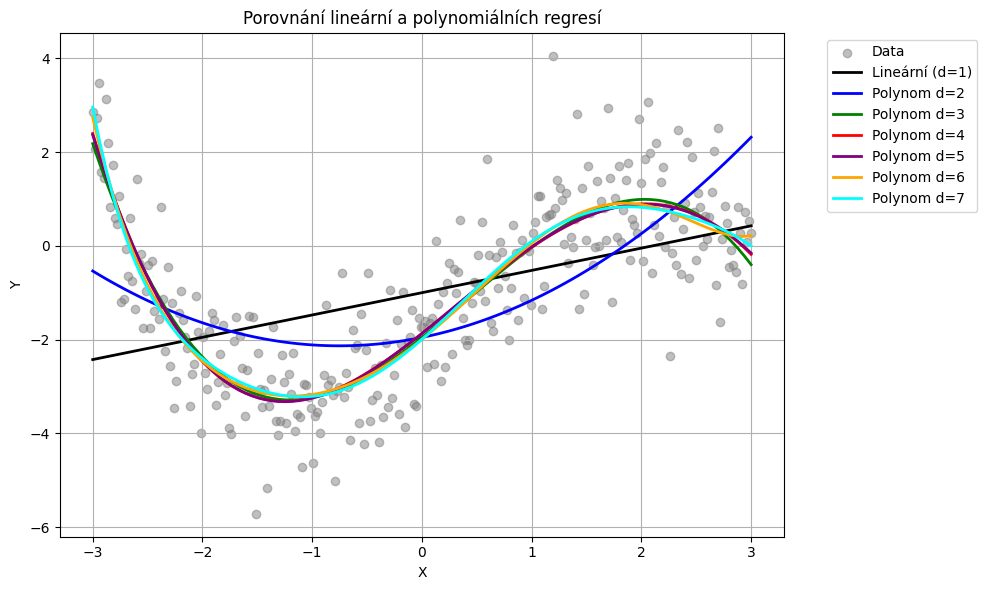

In [13]:
# 5. Společný graf pro všechny regrese
plt.figure(figsize=(10, 6))
plt.scatter(X, y, color='gray', label='Data', alpha=0.5)

# Vytvoření plynulé osy X pro hezčí křivky
X_plot = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)

colors = ['black', 'blue', 'green', 'red', 'purple', 'orange', 'cyan']

for d, color in zip(degrees, colors):
    if d == 1:
        y_plot = models[d].predict(X_plot)
        plt.plot(X_plot, y_plot, color=color, label='Lineární (d=1)', linewidth=2)
    else:
        poly_features = PolynomialFeatures(degree=d)
        X_plot_poly = poly_features.fit_transform(X_plot)
        y_plot = models[d].predict(X_plot_poly)
        plt.plot(X_plot, y_plot, color=color, label=f'Polynom d={d}', linewidth=2)

plt.title('Porovnání lineární a polynomiálních regresí')
plt.xlabel('X')
plt.ylabel('Y')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()

# Uložení grafu
plt.savefig('vsechny_regrese.png', dpi=300)
plt.show()

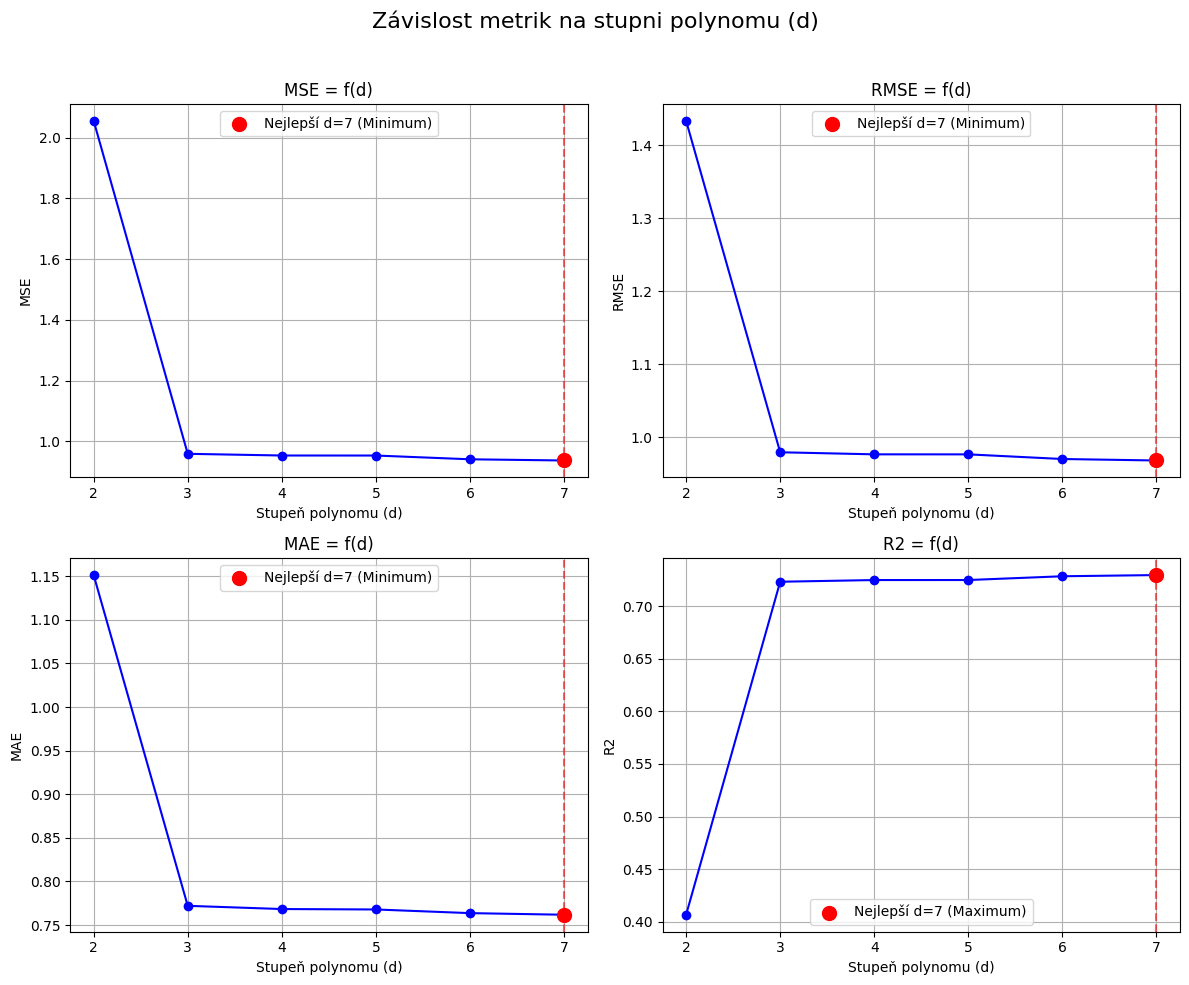

In [14]:
# Odstraníme d=1, protože zadání říká "pro polynomiální regresi (d=2..7)"
df_poly_metrics = df_metrics.loc[2:7]
d_values = df_poly_metrics.index

# Vytvoření obrázku se 4 okny (2x2)
fig, axs = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle('Závislost metrik na stupni polynomu (d)', fontsize=16)

metriky = ['MSE', 'RMSE', 'MAE', 'R2']
pozice = [(0,0), (0,1), (1,0), (1,1)]

for metrika, (i, j) in zip(metriky, pozice):
    axs[i, j].plot(d_values, df_poly_metrics[metrika], marker='o', linestyle='-', color='b')
    axs[i, j].set_title(f'{metrika} = f(d)')
    axs[i, j].set_xlabel('Stupeň polynomu (d)')
    axs[i, j].set_ylabel(metrika)
    axs[i, j].grid(True)

    # 8. Označení nejlepšího stupně
    if metrika in ['MSE', 'RMSE', 'MAE']:
        best_d = df_poly_metrics[metrika].idxmin()
        best_val = df_poly_metrics[metrika].min()
        label = 'Minimum'
    else: # R2 se maximalizuje
        best_d = df_poly_metrics[metrika].idxmax()
        best_val = df_poly_metrics[metrika].max()
        label = 'Maximum'

    # Svislá červená čára a bod pro nejlepší výsledek
    axs[i, j].axvline(best_d, color='red', linestyle='--', alpha=0.6)
    axs[i, j].scatter([best_d], [best_val], color='red', s=100, zorder=5, label=f'Nejlepší d={best_d} ({label})')
    axs[i, j].legend()

plt.tight_layout(rect=[0, 0, 1, 0.96]) # Zarovnání kvůli hlavnímu nadpisu

# 9. Uložení výsledného obrázku
plt.savefig('metriky_zavislost.png', dpi=300)
plt.show()

### 10. Interpretace výsledků
Na základě grafů závislosti metrik na stupni polynomu můžeme vidět, že při zvyšování stupně polynomu (d) chyby (MSE, RMSE, MAE) klesají a hodnota $R^2$ stoupá. 
Zlomový bod (tzv. elbow method) však obvykle nastává u stupně **d = [doplň podle grafu, např. 3 nebo 4]**, kde dojde k nejvýraznějšímu zlepšení. Další zvyšování stupně polynomu (např. d=6 nebo 7) už přináší jen zanedbatelné zlepšení metrik a vizuálně křivka začíná nepříjemně oscilovat a "přeučovat se" (overfitting) na šum v datech. 

Z toho důvodu je nejvhodnějším modelem polynom stupně **d = [X]**. Poskytuje skvělý balanc mezi nízkou chybou a jednoduchostí (hladkostí) modelu.

In [ ]:
# Funkce pro nelineární regresi: y = a * (1 - e^(-bx))
def nelinearni_funkce(x, a, b):
    return a * (1 - np.exp(-b * x))

# Názvy tvých souborů (ujisti se, že jsou ve stejné složce jako notebook)
datasets = {
    'misrala.txt': 'Misrala',
    'BoxBOD.txt': 'BoxBOD'
}

for file, name in datasets.items():
    try:
        # sep='\s+' rozdělí data podle libovolného počtu mezer
        df_nl = pd.read_csv(file, sep='\s+')

        # X je první datový sloupec, y je druhý
        X_nl = df_nl.iloc[:, 0].values
        y_nl = df_nl.iloc[:, 1].values

        # 1. Vizualizace datové sady
        plt.figure(figsize=(8, 5))
        plt.scatter(X_nl, y_nl, label='Původní data', color='black')

        # 2. Vytvoření modelů
        # A) Polynomiální model (zvolíme např. d=3 pro porovnání)
        d = 3
        poly = PolynomialFeatures(degree=d)
        X_poly_nl = poly.fit_transform(X_nl.reshape(-1, 1))
        poly_model = LinearRegression().fit(X_poly_nl, y_nl)

        # B) Nelineární model
        # p0 je náš hrubý odhad [a, b], který pomůže algoritmu najít správnou křivku
        p0_guess = [max(y_nl), 0.01]
        popt, pcov = curve_fit(nelinearni_funkce, X_nl, y_nl, p0=p0_guess, maxfev=10000)
        a_opt, b_opt = popt

        # Vygenerování osy X pro plynulé křivky
        X_plot_nl = np.linspace(X_nl.min(), X_nl.max(), 100)

        # Predikce pro graf
        y_poly_plot = poly_model.predict(poly.transform(X_plot_nl.reshape(-1, 1)))
        y_nl_plot = nelinearni_funkce(X_plot_nl, a_opt, b_opt)

        # 3. Vizualizace výsledků
        plt.plot(X_plot_nl, y_poly_plot, 'b--', label=f'Polynomiální (d={d})')
        plt.plot(X_plot_nl, y_nl_plot, 'r-', label=f'Nelineární: y = {a_opt:.1f}(1 - e^{{-{b_opt:.3f}x}})')

        # Výpočet metrik (RMSE) pro porovnání
        rmse_poly = np.sqrt(mean_squared_error(y_nl, poly_model.predict(X_poly_nl)))
        rmse_nl = np.sqrt(mean_squared_error(y_nl, nelinearni_funkce(X_nl, a_opt, b_opt)))

        plt.title(f'Porovnání modelů - {name}\n(RMSE polynom: {rmse_poly:.2f} | RMSE nelineární: {rmse_nl:.2f})')
        plt.xlabel('X')
        plt.ylabel('Y')
        plt.legend()
        plt.grid(True)

        # Uložení
        plt.savefig(f'{name}_nelinearni_porovnani.png', dpi=300)
        plt.show()

    except FileNotFoundError:
        print(f"Soubor {file} nebyl nalezen. Zkontroluj, zda je název správně a leží u notebooku.")

Soubor misrala.csv nebyl nalezen. Prosím nahraj ho do stejné složky.
Soubor BoxBOD.csv nebyl nalezen. Prosím nahraj ho do stejné složky.
